Adaptive RAG
- query analysis
- rag + self_relfection

In [29]:
#libraries
import os
from typing import List,Literal
from typing_extensions import TypedDict
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langchain_text_splitters import RecursiveCharacterTextSplitter

Api key and LLM setup

In [30]:
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
llm = ChatGroq(
    model="llama-3.1-8b-instant",
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000015CADDEF3B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000015CADD3A4B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

Retriever Setup

In [31]:
embedding = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [32]:
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]
docs = []
for url in urls:
    docs.extend(WebBaseLoader(url).load())
splitter = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=100)
splits = splitter.split_documents(docs)
vs = FAISS.from_documents(documents=docs,embedding=embedding)
retriever = vs.as_retriever(
    search_kwargs = {"k":4}
)
retriever

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000015CAF826CC0>, search_kwargs={'k': 4})

Router for Query Analysis

llm + model to structure output

In [33]:
class RouteQuery(BaseModel):
    datasource: Literal["vectorstore","web_search"] = Field(
        ...,
        description="Given a user question choose to route it to web search or a vectorstore"
    )

structured_llm_router = llm.with_structured_output(RouteQuery)
structured_llm_router

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x0000015CADDEF3B0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000015CADD3A4B0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'RouteQuery', 'description': '', 'parameters': 

In [34]:
system = """You are an expert at routing a user question to a vectorstore or web search. The vectorstore contains documents related
to agents, prompt engineering and adversarial attacks. Use the vectorstore for questions on these topics. Otherwise use web-search"""
route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","{question}")
    ]
)
question_router = route_prompt | structured_llm_router
question_router

ChatPromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an expert at routing a user question to a vectorstore or web search. The vectorstore contains documents related\nto agents, prompt engineering and adversarial attacks. Use the vectorstore for questions on these topics. Otherwise use web-search'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='{question}'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_

testing question router

In [35]:
print(question_router.invoke({"question":"Who won the cricket world cup 2023"}))

datasource='web_search'


In [37]:
print(question_router.invoke({"question":"What is an agent?"}))

datasource='vectorstore'


Retrieval Grader Setup

In [38]:
class GradeDocs(BaseModel):
    binary_score: str = Field(description="Whether the document is relevant to the question. 'yes' or 'no'")

structured_llm_grader = llm.with_structured_output(GradeDocs)
system = """
You are a grader assessing relevance of a retrieved document.

If the document contains keywords, concepts or semantic meaning
related to the user's question, grade it as relevant.

This is a lenient filter.

Respond only with 'yes' or 'no'.
"""
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Retrieved documents: \n\n {document} \n\n User Question: {question}")
    ]
)
retrieval_grader = grade_prompt | structured_llm_grader
retrieval_grader

ChatPromptTemplate(input_variables=['document', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are a grader assessing relevance of a retrieved document.\n\nIf the document contains keywords, concepts or semantic meaning\nrelated to the user's question, grade it as relevant.\n\nThis is a lenient filter.\n\nRespond only with 'yes' or 'no'.\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['document', 'question'], input_types={}, partial_variables={}, template='Retrieved documents: \n\n {document} \n\n User Question: {question}'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'ma

testing retrieval grader

In [44]:
question = "agent memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content[:800]
print(retrieval_grader.invoke({"question":question,"document":doc_txt}))

binary_score='yes'


Generate answer Setup

In [40]:
def format_docs(docs: List[Document]) -> str:
    return "\n\n".join(doc.page_content for doc in docs)

In [41]:
rag_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """You are an intelligent assistant for Retrieval-Augmented Generation (RAG).

You will be given retrieved context and a user question.

Instructions:
- Answer ONLY using the provided context.
- If the answer cannot be determined from the context, say:
  "I don't have enough information in the provided documents to answer that."
- Do not make up facts.
- Do not use outside knowledge.
- Keep the answer clear, concise, and accurate.
- If appropriate, organize the answer using bullet points or numbered lists.
""",
        ),
        (
            "human",
            """Context:
{context}

Question:
{question}

Answer:""",
        ),
    ]
)

rag_chain = (
    rag_prompt
    | llm
    | StrOutputParser()
)
rag_chain

ChatPromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template='You are an intelligent assistant for Retrieval-Augmented Generation (RAG).\n\nYou will be given retrieved context and a user question.\n\nInstructions:\n- Answer ONLY using the provided context.\n- If the answer cannot be determined from the context, say:\n  "I don\'t have enough information in the provided documents to answer that."\n- Do not make up facts.\n- Do not use outside knowledge.\n- Keep the answer clear, concise, and accurate.\n- If appropriate, organize the answer using bullet points or numbered lists.\n'), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'question'], input_types={}, partial_variables={}, template='Context:\n{context}\n\nQuestion:\n{question}\n\nAnswer:'), additional_kwargs={})])
| Ch

testing the rag_chain

In [42]:
ans = rag_chain.invoke({"context":doc_txt,"question":question})
print(ans)

I don't have enough information in the provided documents to answer that.


Self reflection setup

Hallucination Grader

In [45]:
class GradeHallucination(BaseModel):
    binary_score: str = Field(description="Whether the answer is supported by the documents. 'yes' or 'no'")
    
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a grader assessing whether an answer is grounded in
retrieved documents.

Return:

yes → answer is supported

no → answer contains hallucinations

Respond only with 'yes' or 'no'.
""",
        ),
        (
            "human",
            """
Retrieved documents:

{documents}

LLM Answer:

{generation}
""",
        ),
    ]
)

hallucination_grader = (
    hallucination_prompt
    | llm.with_structured_output(GradeHallucination)
)
hallucination_grader

ChatPromptTemplate(input_variables=['documents', 'generation'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are a grader assessing whether an answer is grounded in\nretrieved documents.\n\nReturn:\n\nyes → answer is supported\n\nno → answer contains hallucinations\n\nRespond only with 'yes' or 'no'.\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['documents', 'generation'], input_types={}, partial_variables={}, template='\nRetrieved documents:\n\n{documents}\n\nLLM Answer:\n\n{generation}\n'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens

Answer Grader

In [46]:
class GradeAnswer(BaseModel):
    binary_score: str = Field(description="Whether the answer addresses the user's question. 'yes' or 'no'")

answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are grading whether an answer addresses a user's question.

Respond with

yes

or

no
""",
        ),
        (
            "human",
            """
Question:

{question}

Generated answer:

{generation}
""",
        ),
    ]
)
answer_grader = (
    answer_prompt
    | llm.with_structured_output(GradeAnswer)
)
answer_grader

ChatPromptTemplate(input_variables=['generation', 'question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are grading whether an answer addresses a user's question.\n\nRespond with\n\nyes\n\nor\n\nno\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['generation', 'question'], input_types={}, partial_variables={}, template='\nQuestion:\n\n{question}\n\nGenerated answer:\n\n{generation}\n'), additional_kwargs={})])
| _ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_

Query Rewriter

In [49]:
rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
You are a query rewriter.

Rewrite the user's question to improve retrieval quality.

Do not answer the question.

Only rewrite it.

Do not return your explanation
""",
        ),
        (
            "human",
            """
Original Question:

{question}
""",
        ),
    ]
)
query_rewriter = (
    rewrite_prompt
    | llm
    | StrOutputParser()
)
query_rewriter

ChatPromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, messages=[SystemMessagePromptTemplate(prompt=PromptTemplate(input_variables=[], input_types={}, partial_variables={}, template="\nYou are a query rewriter.\n\nRewrite the user's question to improve retrieval quality.\n\nDo not answer the question.\n\nOnly rewrite it.\n\nDo not return your explanation\n"), additional_kwargs={}), HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['question'], input_types={}, partial_variables={}, template='\nOriginal Question:\n\n{question}\n'), additional_kwargs={})])
| ChatGroq(metadata={'lc_versions': {'langchain-core': '1.4.8', 'langchain': '1.3.11'}}, output_version=None, profile={'name': 'Llama 3.1 8B Instant', 'release_date': '2024-07-23', 'last_updated': '2024-07-23', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 131072, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_output

In [51]:
query_rewriter.invoke({"question":question})

'What are the characteristics and implications of agent memory in artificial intelligence?'

Web Search tool

In [52]:
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(max_results=3)
web_search_tool

TavilySearch(max_results=3, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None))

Graph State

In [53]:
class GraphState(TypedDict):
    question: str
    documents: List[Document]
    generation: str
    web_search: str
    rewrite_count: int

In [54]:
def print_node(nodename: str):
    print("\n"+"="*60)
    print(f"Node: {nodename}")
    print("="*60)

Nodes Setup

In [55]:
def retrieve(state: GraphState):
    print_node("Retrieve")
    question = state["question"]
    documents = retriever.invoke(question)
    print(f"No of docs retrieved: {len(documents)}")
    return {
        "question": question,
        "documents": documents,
    }

def grade_documents(state: GraphState):
    print_node("Grade Documents")
    question = state["question"]
    documents = state["documents"]
    filtered_docs = []
    web_search = "No"
    for i,doc in enumerate(documents):
        score = retrieval_grader.invoke(
            {
                "question": question,
                "document": doc.page_content,
            }
        )
        if score.binary_score.lower() == "yes":
            print(f"Doc{i+1} relevant")
            filtered_docs.append(doc)
        else:
            print(f"Doc{i+1} irrelevant")

    if len(filtered_docs) == 0:
        web_search = "Yes"
    return {
        "question": question,
        "documents": filtered_docs,
        "web_search": web_search,
    }

def transform_query(state: GraphState):
    print_node("Transform query")
    question = state["question"]
    better_question = query_rewriter.invoke(
        {
            "question": question
        }
    )

    print("Original :", question)
    print("Rewritten:", better_question)

    return {
        "question": better_question,
        "documents": state["documents"],
        "rewrite_count": state.get("rewrite_count",0)+1
    }

def web_search_node(state: GraphState):
    print_node("Web Search")
    question = state["question"]
    documents = state["documents"]
    results = web_search_tool.invoke(
        {
            "query": question
        }
    )
    web_results = "\n\n".join(
        result["content"] for result in results
    )
    documents.append(
        Document(page_content=web_results)
    )
    print("Web results added.")
    return {
        "question": question,
        "documents": documents,
    }

def generate(state: GraphState):
    print_node("Generate")
    question = state["question"]
    documents = state["documents"]
    generation = rag_chain.invoke(
        {
            "context": format_docs(documents),
            "question": question,
        }
    )
    return {
        "question": question,
        "documents": documents,
        "generation": generation,
    }

def grade_generation_wrt_documents_and_question(
    state: GraphState,
):
    print_node("Grade Generation")
    question = state["question"]
    documents = state["documents"]
    generation = state["generation"]
    hallucination_score = hallucination_grader.invoke(
        {
            "documents": format_docs(documents),
            "generation": generation,
        }
    )
    if hallucination_score.binary_score.lower() == "yes":
        print("Generation grounded.")
        answer_score = answer_grader.invoke(
            {
                "question": question,
                "generation": generation,
            }
        )
        if answer_score.binary_score.lower() == "yes":
            print("Answer addresses question.")
            return "useful"
        else:
            print("Answer does not address question.")
            return "not useful"
    else:
        print("Hallucination detected.")
        return "not supported"

MAX_REWRITES = 2
def decide_to_generate(state: GraphState):
    print_node("Decide to generate")
    if state["web_search"] == "Yes":
        if state.get("rewrite_count", 0) >= MAX_REWRITES:
            print("Maximum rewrites reached.")
            print("Proceeding with available documents.")
            return "generate"
        print("Documents insufficient.")
        print("Rewriting query...")
        return "transform_query"

    print("Documents sufficient.")
    print("Generating answer...")
    return "generate"

def route_question(state: GraphState):
    question = state["question"]
    source = question_router.invoke({"question":question})
    if source.datasource == "web_search":
        return "web_search"
    elif source.datasource == "vectorstore":
        return "vectorstore"

Building the Graph

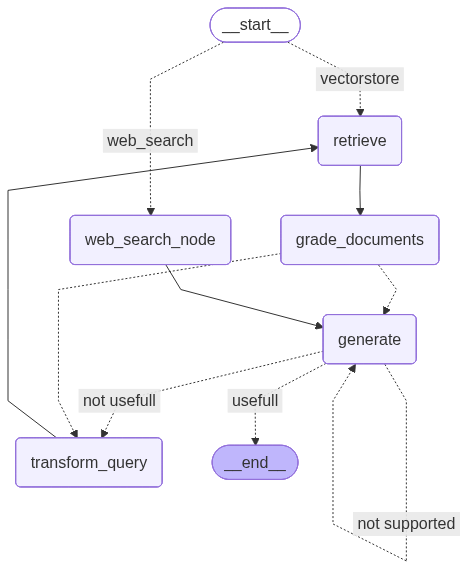

In [56]:
workflow = StateGraph(GraphState)

#nodes
workflow.add_node("retrieve", retrieve)
workflow.add_node("grade_documents",grade_documents)
workflow.add_node("transform_query",transform_query)
workflow.add_node("web_search_node",web_search_node)
workflow.add_node("generate",generate)

#edges
workflow.add_conditional_edges(
    START,
    route_question,
    {
        "web_search":"web_search_node",
        "vectorstore":"retrieve"
    }
)
workflow.add_edge("web_search_node","generate")
workflow.add_edge("retrieve","grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query":"transform_query",
        "generate":"generate"
    }
)
workflow.add_edge("transform_query","retrieve")
workflow.add_conditional_edges(
    "generate",
    grade_generation_wrt_documents_and_question,
    {
        "usefull": END,
        "not usefull": "transform_query",
        "not supported": "generate"
    }
)
graph = workflow.compile()
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))